# Analysis of GRB 190114C with Fermi LAT

In [58]:
import warnings
warnings.simplefilter("ignore")
from threeML import *
from threeML.utils.data_download.Fermi_LAT.download_LAT_data import LAT_dataset
import matplotlib.pyplot as plt
import numpy as np
import astropy.units as u
from astropy.io import fits

### See which IRFs are available to use

In [59]:
from GtBurst import IRFS

irfs = IRFS.IRFS.keys()
irfs

odict_keys(['p7rep_transient', 'p7rep_source', 'p7rep_clean', 'p7rep_ultraclean', 'p8r2_transient100e', 'p8r2_transient100', 'p8r2_transient020e', 'p8r2_transient020', 'p8r2_transient010e', 'p8r2_transient010', 'p8r2_source', 'p8r2_clean', 'p8r2_ultraclean', 'p8r2_ultracleanveto', 'p8r2_transient100s', 'p8r2_transient015s', 'p8_transient100e', 'p8_transient100', 'p8_transient020e', 'p8_transient020', 'p8_transient010e', 'p8_transient010', 'p8_source', 'p8_clean', 'p8_ultraclean', 'p8_ultracleanveto', 'p8_sourceveto', 'p8_transient100s', 'p8_transient015s'])

### Define the basic info of the GRB

In [65]:
trigger_name = "bn190114873"
tstart = 0
tstop = 1000
roi = 10 #degrees
zmax = 110.0
irf = "p8_transient020e"
met = 569192227.626
ra = 54.51
dec = -26.939

### Download LAT data (FT1 and FT2)

In [66]:
LATdataset = LAT_dataset()

LATdataset.make_LAT_dataset(
    ra=ra,
    dec=dec,
    radius=12,
    trigger_time=met,
    tstart=tstart,
    tstop=tstop,
    data_type="Extended",
    destination_directory=".",
    Emin=100.0, #100 MeV
    Emax=100000.0, #100 GeV
)

### Select the events based on the cut configuration

In [67]:
LATdataset.extract_events(roi, zmax, irf)

time -p gtmktime scfile=/shared/bn190114873/gll_ft2_tr_bn190114873_v00.fit sctable="SC_DATA" filter="(DATA_QUAL>0 || DATA_QUAL==-1) && LAT_CONFIG==1 && IN_SAA!=T && LIVETIME>0 && (ANGSEP(RA_ZENITH,DEC_ZENITH,54.51,-26.939)<=(110.0-10))" roicut=no evfile=/shared/bn190114873/gll_ft1_tr_bn190114873_v00.fit evtable="EVENTS" outfile="gll_ft1_tr_bn190114873_v00_mkt.fit" apply_filter=yes overwrite=no header_obstimes=yes tstart=569192227.626 tstop=569193227.626 gtifile="default" chatter=2 clobber=yes debug=no gui=no mode="ql"
real 0.03
user 0.03
sys 0.00

Using 305 data

time -p gtselect infile=gll_ft1_tr_bn190114873_v00_mkt.fit outfile=gll_ft1_tr_bn190114873_v00_filt.fit ra=54.51 dec=-26.939 rad=10.0 tmin=569192227.626 tmax=569193227.626 emin=100.0 emax=100000.0 zmin=0.0 zmax=110.0 evclass=8 evtype=3 convtype=-1 phasemin=0.0 phasemax=1.0 evtable="EVENTS" chatter=2 clobber=yes debug=no gui=no mode="ql"
Done.
real 0.05
user 0.04
sys 0.00

Selected 254 events.


22:14:56 INFO      Extracted 254 events                                                    ]8;id=5343815;file:///opt/anaconda/envs/fermi/lib/python3.11/site-packages/threeML/utils/data_download/Fermi_LAT/download_LAT_data.py\download_LAT_data.py]8;;\:]8;id=5343816;file:///opt/anaconda/envs/fermi/lib/python3.11/site-packages/threeML/utils/data_download/Fermi_LAT/download_LAT_data.py#640\640]8;;\

### Open the filtered FT1 and get the events

In [68]:
with fits.open(LATdataset.filt_file) as event_file:
    lat_events = event_file["EVENTS"].data
event_times = lat_events["TIME"] - grb_info["MET"]

### Plot the lightcurve and the events

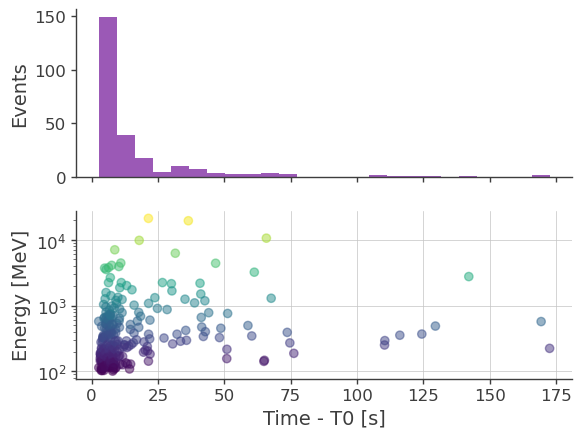

In [69]:
%matplotlib inline
fig, axs = plt.subplots(2, 1, sharex=True)
plt.sca(axs[0])
plt.hist(event_times);
plt.ylabel('Events')
plt.sca(axs[1])
plt.scatter(event_times, lat_events['ENERGY'], marker='o', c=lat_events['ENERGY'], norm='log',
            alpha=0.5, zorder=20)
plt.yscale('log')
plt.ylabel('Energy [MeV]')
plt.xlabel('Time - T0 [s]')
plt.grid(True)
plt.show()

### Define the temporal binning

In [70]:
tstarts = "0,10,30,80" #seconds
tstops = "10,30,80,180" #seconds

### Configure and run the TransientLATDataBuilder to bin LAT data over the selected intervals

In [71]:
analysis_builder = TransientLATDataBuilder(
    LATdataset.grb_name,
    outfile=LATdataset.grb_name,
    roi=roi,
    tstarts=tstarts,
    tstops=tstops,
    irf=irf,
    zmax=zmax,
    galactic_model="template",
    particle_model="isotr template",
    datarepository=".",
)
df = analysis_builder.display(get=True)

outfile                      190114873
roi                                 10
tstarts                     0,10,30,80
tstops                    10,30,80,180
zmax                             110.0
emin                             100.0
emax                          100000.0
irf                   p8_transient020e
galactic_model                template
particle_model          isotr template
source_model                 PowerLaw2
tsmin                             20.0
strategy                          time
thetamax                         180.0
spectralfiles                       no
liketype                      unbinned
optimizeposition                    no
datarepository                       .
ltcube                                
expomap                               
ulphindex                           -2
flemin                             100
flemax                           10000
fgl_mode                          fast
filter_GTI                       False
likelihood_profile       

In [72]:
LAT_observations = analysis_builder.run(recompute_intervals=True)

22:15:09 INFO      Changing permission to                                              ]8;id=5343821;file:///opt/anaconda/envs/fermi/lib/python3.11/site-packages/threeML/utils/data_builders/fermi/lat_transient_builder.py\lat_transient_builder.py]8;;\:]8;id=5343822;file:///opt/anaconda/envs/fermi/lib/python3.11/site-packages/threeML/utils/data_builders/fermi/lat_transient_builder.py#719\719]8;;\
                  /opt/anaconda/envs/fermi/lib/python3.11/site-packages/fermitools/GtB                             
                  urst/scripts/doTimeResolvedLike.py                                                               

         INFO      About to run the following command:                                 ]8;id=5343827;file:///opt/anaconda/envs/fermi/lib/python3.11/site-packages/threeML/utils/data_builders/fermi/lat_transient_builder.py\lat_transient_builder.py]8;;\:]8;id=5343828;file:///opt/anaconda/envs/fermi/lib/python3.11/site-packages/threeML/utils/data_builders/fermi/lat_transient_builder.py#724\724]8;;\
                  /opt/anaconda/envs/fermi/lib/python3.11/site-packages/fermitools/GtB                             
                  urst/scripts/doTimeResolvedLike.py 190114873 --outfile '190114873'                               
                  --roi 10.000000 --tstarts '0,10,30,80' --tstops '10,30,80,180'                                   
                  --zmax 110.000000 --emin 100.000000 --emax 100000.000000 --irf                                   
                  'p8_transient020e' --galactic_model 'template' --particle_model                                  
                  'isotr template' --source_model 'PowerLaw2' --tsmin 20.000000                                    
                  --strategy 'time' --thetamax 180.000000 --spectralfiles 'no'                                     
                  --liketype 'unbinned' --optimizeposition 'no' --datarepository '.'                               
                  --ltcube '' --expomap '' --ulphindex -2.000000 --flemin 100.000000                               
                  --flemax 10000.000000 --fgl_mode 'fast'                                                          

         INFO      You have choosen to recompute the time intervals in this folder     ]8;id=5343833;file:///opt/anaconda/envs/fermi/lib/python3.11/site-packages/threeML/utils/data_builders/fermi/lat_transient_builder.py\lat_transient_builder.py]8;;\:]8;id=5343834;file:///opt/anaconda/envs/fermi/lib/python3.11/site-packages/threeML/utils/data_builders/fermi/lat_transient_builder.py#736\736]8;;\

         INFO      The older entries will be moved to                                  ]8;id=5343839;file:///opt/anaconda/envs/fermi/lib/python3.11/site-packages/threeML/utils/data_builders/fermi/lat_transient_builder.py\lat_transient_builder.py]8;;\:]8;id=5343840;file:///opt/anaconda/envs/fermi/lib/python3.11/site-packages/threeML/utils/data_builders/fermi/lat_transient_builder.py#742\742]8;;\
                  tmp_2d7f9245-f2e2-4ea4-96a6-9e41722f7a40                                                         

 **********
 **    1 **SET PRINT     .000    
 **********
 **********
 **    2 **SET NOWARN 
 **********

 PARAMETER DEFINITIONS:
    NO.   NAME         VALUE      STEP SIZE      LIMITS
     1 'Integral  '    .10000E-01   1.0000         .10000E-04   1000.0    
     2 'Index     '   -2.0000       1.0000        -6.0000       .10000E-01
     3 'Value     '    1.0000       1.0000         .70000       1.3000    
     4 'Normalizat'    1.0000       1.0000         .10000       10.000    
 **********
 **    3 **SET ERR    .5000    
 **********
 **********
 **    4 **SET GRAD    1.000    
 **********
 **********
 **    5 **MINIMIZE    900.0       2.000    
 **********

 MIGRAD MINIMIZATION HAS CONVERGED.

 MIGRAD WILL VERIFY CONVERGENCE AND ERROR MATRIX.

 MIGRAD MINIMIZATION HAS CONVERGED.

 FCN=   272.4244     FROM MIGRAD    STATUS=CONVERGED     70 CALLS       71 TOTAL
                     EDM=   .21E-04  STRATEGY=1  ERROR MATRIX UNCERTAINTY=  8.6%

  EXT PARAMETER                            

...

         INFO      we will grab the data file for you.                                 ]8;id=5343887;file:///opt/anaconda/envs/fermi/lib/python3.11/site-packages/threeML/utils/data_builders/fermi/lat_transient_builder.py\lat_transient_builder.py]8;;\:]8;id=5343888;file:///opt/anaconda/envs/fermi/lib/python3.11/site-packages/threeML/utils/data_builders/fermi/lat_transient_builder.py#819\819]8;;\

         INFO      copied ./bn190114873/gll_ft2_tr_bn190114873_v00.fit to              ]8;id=5343893;file:///opt/anaconda/envs/fermi/lib/python3.11/site-packages/threeML/utils/data_builders/fermi/lat_transient_builder.py\lat_transient_builder.py]8;;\:]8;id=5343894;file:///opt/anaconda/envs/fermi/lib/python3.11/site-packages/threeML/utils/data_builders/fermi/lat_transient_builder.py#838\838]8;;\
                  interval30.0-80.0/gll_ft2_tr_bn190114873_v00.fit                                                 

         INFO      The ft2 file does not exist. Please examine!                        ]8;id=5343899;file:///opt/anaconda/envs/fermi/lib/python3.11/site-packages/threeML/utils/data_builders/fermi/lat_transient_builder.py\lat_transient_builder.py]8;;\:]8;id=5343900;file:///opt/anaconda/envs/fermi/lib/python3.11/site-packages/threeML/utils/data_builders/fermi/lat_transient_builder.py#818\818]8;;\

         INFO      we will grab the data file for you.                                 ]8;id=5343905;file:///opt/anaconda/envs/fermi/lib/python3.11/site-packages/threeML/utils/data_builders/fermi/lat_transient_builder.py\lat_transient_builder.py]8;;\:]8;id=5343906;file:///opt/anaconda/envs/fermi/lib/python3.11/site-packages/threeML/utils/data_builders/fermi/lat_transient_builder.py#819\819]8;;\

         INFO      copied ./bn190114873/gll_ft2_tr_bn190114873_v00.fit to              ]8;id=5343911;file:///opt/anaconda/envs/fermi/lib/python3.11/site-packages/threeML/utils/data_builders/fermi/lat_transient_builder.py\lat_transient_builder.py]8;;\:]8;id=5343912;file:///opt/anaconda/envs/fermi/lib/python3.11/site-packages/threeML/utils/data_builders/fermi/lat_transient_builder.py#838\838]8;;\
                  interval80.0-180.0/gll_ft2_tr_bn190114873_v00.fit                                                

### Create the corresponding LAT plugins

In [73]:
LAT_plugins = {}
for l in LAT_observations:
    LAT_name = "LAT%dX%d" % (int(l.tstart), int(l.tstop))
    LAT_plugins[LAT_name] = l.to_LATLike()
LAT_plugins.keys()

FermiLATLike - GTI SUM =  10.0
FermiLATLike - GTI SUM =  20.0
FermiLATLike - GTI SUM =  50.0
FermiLATLike - GTI SUM =  97.97399997711182


dict_keys(['LAT0X10', 'LAT10X30', 'LAT30X80', 'LAT80X180'])

### Create the spectral model

In [74]:
powerlaw = Powerlaw_flux()
powerlaw.a = 1e+5 #keV -> 100 MeV
powerlaw.b = 1e+7 #keV -> 10 GeV
powerlaw.F.bounds = (1e-6, 1e6)
powerlaw.index.bounds = (-3, 0)
source = PointSource(trigger_name, grb_info["RA"], dec=grb_info["DEC"], spectral_shape=powerlaw)
model = Model(source)
model.display(complete=True)

22:17:22 WARNING   We have set the min_value of Powerlaw_flux.F to 1e-99 because there was a       ]8;id=5343917;file:///opt/anaconda/envs/fermi/lib/python3.11/site-packages/astromodels/core/parameter.py\parameter.py]8;;\:]8;id=5343918;file:///opt/anaconda/envs/fermi/lib/python3.11/site-packages/astromodels/core/parameter.py#715\715]8;;\
                  postive transform                                                                                

Model summary:
==============

                  N
Point sources     1
Extended sources  0
Particle sources  0

Free parameters (2):
--------------------

                    value min_value  max_value      unit
bn190114873...F       1.0  0.000001  1000000.0  s-1 cm-2
bn190114873...index  -2.0      -3.0        0.0          

Fixed parameters (4):
---------------------

                               value min_value max_value unit
bn190114873.position.ra        54.51       0.0     360.0  deg
bn190114873.position.dec     -26.939     -90.0      90.0  deg
bn190114873...a             100000.0      None      None  keV
bn190114873...b           10000000.0      None      None  keV

Properties (0):
--------------------

(none)


Linked parameters (0):
----------------------

(none)

Independent variables:
----------------------

(none)

Linked functions (0):
----------------------

(none)

### Run the ML fit in each time interval

In [75]:
analysis = []

for name, plugin in LAT_plugins.items():
    this_model = clone_model(model)
    datalist = DataList(plugin)
    jl = JointLikelihood(this_model, datalist, verbose=False)

    # This is needed to fix the galactic template to 1 (if needed) 
    this_model[name + "_GalacticTemplate_Value"].value = 1.0
    this_model[name + "_GalacticTemplate_Value"].fix = True
    this_model[name + "_IsotropicTemplate_Normalization"].fix = True
    this_model.display(complete=True)

    jl.set_minimizer("minuit")
    jl.fit()
    analysis.append(jl)



Found Isotropic template for irf P8R3_TRANSIENT020E_V3: /opt/anaconda/envs/fermi/share/fermitools/refdata/fermi/galdiffuse/iso_P8R3_TRANSIENT020E_V3_v1.txt

Found Galactic template for IRF. P8R3_TRANSIENT020E_V3: /opt/anaconda/envs/fermi/share/fermitools/refdata/fermi/galdiffuse/gll_iem_v07.fits

Cutting the template around the ROI: 



22:17:34 INFO      set the minimizer to minuit                                             ]8;id=5343923;file:///opt/anaconda/envs/fermi/lib/python3.11/site-packages/threeML/classicMLE/joint_likelihood.py\joint_likelihood.py]8;;\:]8;id=5343924;file:///opt/anaconda/envs/fermi/lib/python3.11/site-packages/threeML/classicMLE/joint_likelihood.py#1017\1017]8;;\

Model summary:
==============

                  N
Point sources     1
Extended sources  0
Particle sources  0

Free parameters (2):
--------------------

                    value min_value  max_value      unit
bn190114873...F       1.0  0.000001  1000000.0  s-1 cm-2
bn190114873...index  -2.0      -3.0        0.0          

Fixed parameters (6):
---------------------

                                              value min_value max_value unit
bn190114873.position.ra                       54.51       0.0     360.0  deg
bn190114873.position.dec                    -26.939     -90.0      90.0  deg
bn190114873...a                            100000.0      None      None  keV
bn190114873...b                          10000000.0      None      None  keV
LAT0X10_GalacticTemplate_Value                  1.0       0.5       1.5     
LAT0X10_IsotropicTemplate_Normalization         1.0       0.1       5.0     

Properties (0):
--------------------

(none)


Linked parameters (0):
----------------------

(none)

Independent variables:
----------------------

(none)

Linked functions (0):
----------------------

(none)

         INFO      set the minimizer to MINUIT                                             ]8;id=5343929;file:///opt/anaconda/envs/fermi/lib/python3.11/site-packages/threeML/classicMLE/joint_likelihood.py\joint_likelihood.py]8;;\:]8;id=5343930;file:///opt/anaconda/envs/fermi/lib/python3.11/site-packages/threeML/classicMLE/joint_likelihood.py#1034\1034]8;;\

Best fit values:

...

1.00,-0.39
-0.39,1.00


Values of -log(likelihood) at the minimum:

,-log(likelihood)
LAT80X180,73.78036
total,73.78036


Values of statistical measures:

,statistical measures
AIC,153.960720
BIC,151.719603


### Display the results and plot the model with residuals

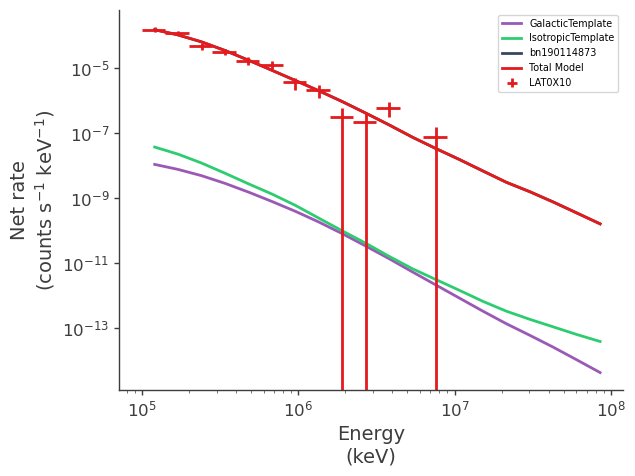

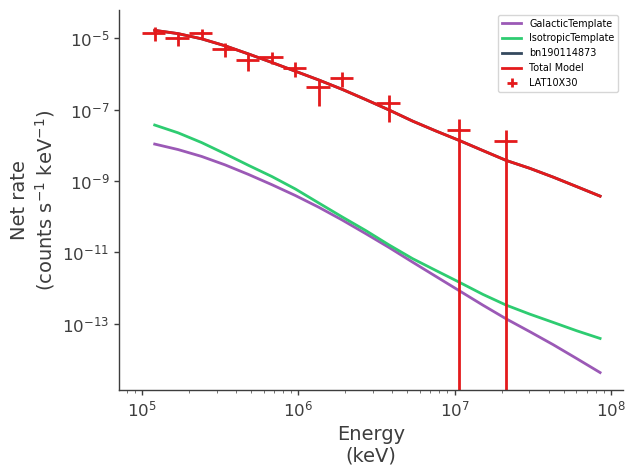

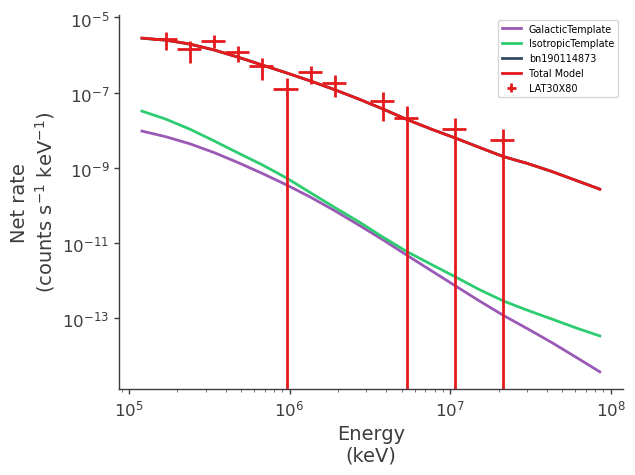

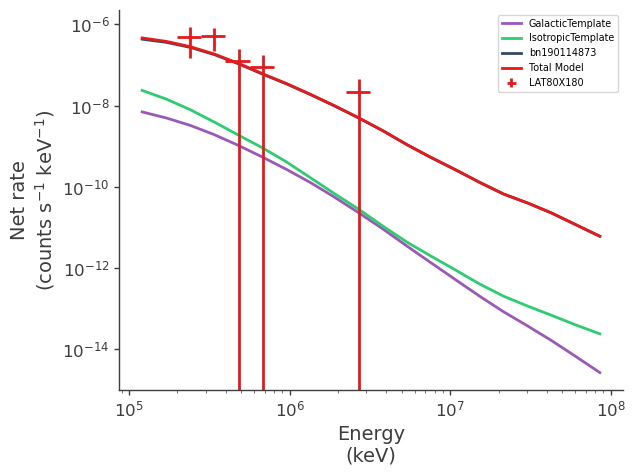

In [76]:
for i, a in enumerate(analysis):
    analysis[1].results.get_data_frame()
    display_spectrum_model_counts(a, show_residuals=False);

### Plot the spectra

processing MLE analyses:   0%|                                                     | 0/4 [00:00<?, ?it/s]

Propagating errors:   0%|                                                        | 0/100 [00:00<?, ?it/s]

Propagating errors:   0%|                                                        | 0/100 [00:00<?, ?it/s]

Propagating errors:   0%|                                                        | 0/100 [00:00<?, ?it/s]

Propagating errors:   0%|                                                        | 0/100 [00:00<?, ?it/s]

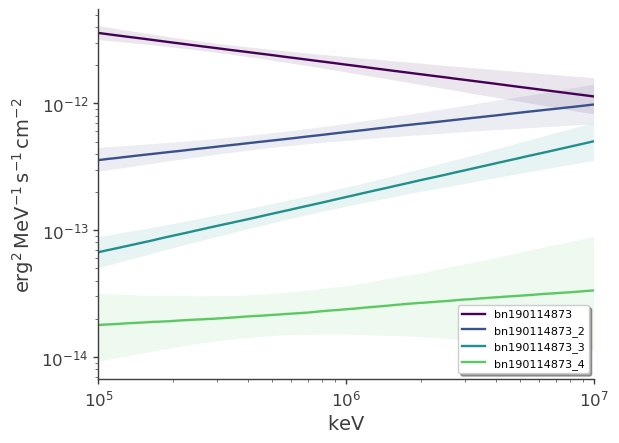

In [77]:
fig = plot_spectra(
    *[a.results for a in analysis],
    ene_min=100 * u.MeV,
    ene_max=10 * u.GeV,
    flux_unit="erg2/(cm2 s MeV)",
    fit_cmap="viridis",
    contour_cmap="viridis",
    contour_style_kwargs=dict(alpha=0.1),
)

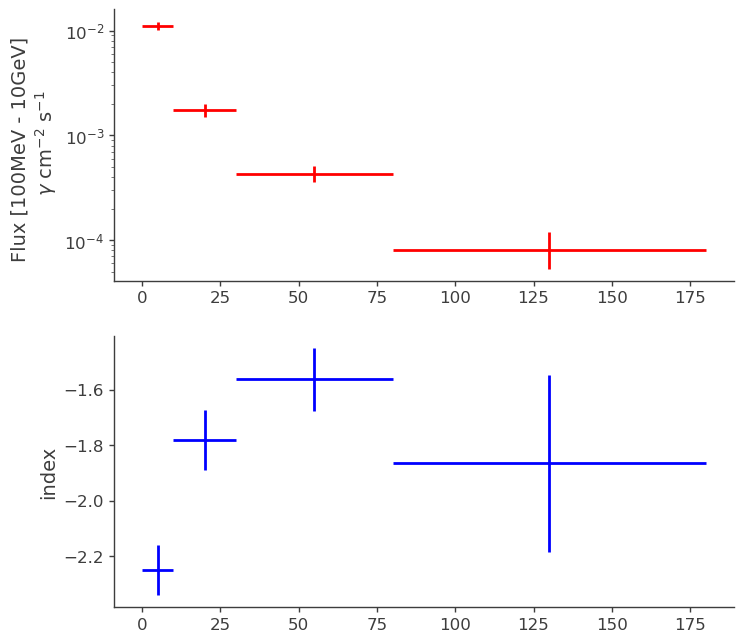

In [82]:
variates = ["F", "index"]
y = {}
for n in variates:
    y[n] = []
    y[n + "_p"] = []
    y[n + "_n"] = []
x = []
dx = []

for i, l in enumerate(LAT_observations):
    x.append((float(l.tstop) + float(l.tstart)) / 2)
    dx.append((float(l.tstop) - float(l.tstart)) / 2)
    jl = analysis[i]
    res = jl.results
    mod = res.optimized_model
    ps = mod.point_sources

    for n in variates:
        var = res.get_variates("%s.spectrum.main.Powerlaw_flux.%s" % (trigger_name, n))
        y[n].append(var.median)
        y[n + "_p"].append(var.equal_tail_interval()[1] - var.median)
        y[n + "_n"].append(var.median - var.equal_tail_interval()[0])


fig = plt.figure(figsize=(8, 12))
colors = ["r", "b"]
ylabels = ["Flux [100MeV - 10GeV] \n $\gamma$ cm$^{-2}$ s$^{-1}$", "index"]
for i, n in enumerate(variates):
    plt.subplot(len(variates) + 1, 1, i + 1)
    plt.errorbar(x, y[n], xerr=dx, yerr=(y[n + "_n"], y[n + "_p"]), ls="", c=colors[i])
    if i == 0:
        plt.yscale("log")
    plt.ylabel(ylabels[i])

### Compute the TS and print their values

In [83]:
TS = {}
for a in analysis:
    TS[list(a.data_list.keys())[0]] = a.compute_TS(trigger_name, a.results.get_statistic_frame())['TS'].iloc[0]


Found Isotropic template for irf P8R3_TRANSIENT020E_V3: /opt/anaconda/envs/fermi/share/fermitools/refdata/fermi/galdiffuse/iso_P8R3_TRANSIENT020E_V3_v1.txt

Found Galactic template for IRF. P8R3_TRANSIENT020E_V3: /opt/anaconda/envs/fermi/share/fermitools/refdata/fermi/galdiffuse/gll_iem_v07.fits

Cutting the template around the ROI: 



22:22:59 WARNING   External parameter LAT0X10_GalacticTemplate_Value already exist in the model.       ]8;id=5344115;file:///opt/anaconda/envs/fermi/lib/python3.11/site-packages/astromodels/core/model.py\model.py]8;;\:]8;id=5344116;file:///opt/anaconda/envs/fermi/lib/python3.11/site-packages/astromodels/core/model.py#593\593]8;;\
                  Overwriting it...                                                                                

         WARNING   External parameter LAT0X10_IsotropicTemplate_Normalization already exist in the     ]8;id=5344121;file:///opt/anaconda/envs/fermi/lib/python3.11/site-packages/astromodels/core/model.py\model.py]8;;\:]8;id=5344122;file:///opt/anaconda/envs/fermi/lib/python3.11/site-packages/astromodels/core/model.py#593\593]8;;\
                  model. Overwriting it...                                                                         

22:22:59 INFO      set the minimizer to minuit                                             ]8;id=5344127;file:///opt/anaconda/envs/fermi/lib/python3.11/site-packages/threeML/classicMLE/joint_likelihood.py\joint_likelihood.py]8;;\:]8;id=5344128;file:///opt/anaconda/envs/fermi/lib/python3.11/site-packages/threeML/classicMLE/joint_likelihood.py#1017\1017]8;;\

         INFO      set the minimizer to minuit                                             ]8;id=5344133;file:///opt/anaconda/envs/fermi/lib/python3.11/site-packages/threeML/classicMLE/joint_likelihood.py\joint_likelihood.py]8;;\:]8;id=5344134;file:///opt/anaconda/envs/fermi/lib/python3.11/site-packages/threeML/classicMLE/joint_likelihood.py#1017\1017]8;;\

...

22:23:29 INFO      set the minimizer to minuit                                             ]8;id=5344235;file:///opt/anaconda/envs/fermi/lib/python3.11/site-packages/threeML/classicMLE/joint_likelihood.py\joint_likelihood.py]8;;\:]8;id=5344236;file:///opt/anaconda/envs/fermi/lib/python3.11/site-packages/threeML/classicMLE/joint_likelihood.py#1017\1017]8;;\

         INFO      set the minimizer to minuit                                             ]8;id=5344241;file:///opt/anaconda/envs/fermi/lib/python3.11/site-packages/threeML/classicMLE/joint_likelihood.py\joint_likelihood.py]8;;\:]8;id=5344242;file:///opt/anaconda/envs/fermi/lib/python3.11/site-packages/threeML/classicMLE/joint_likelihood.py#1017\1017]8;;\


Found Isotropic template for irf P8R3_TRANSIENT020E_V3: /opt/anaconda/envs/fermi/share/fermitools/refdata/fermi/galdiffuse/iso_P8R3_TRANSIENT020E_V3_v1.txt

Found Galactic template for IRF. P8R3_TRANSIENT020E_V3: /opt/anaconda/envs/fermi/share/fermitools/refdata/fermi/galdiffuse/gll_iem_v07.fits

Cutting the template around the ROI: 



22:23:34 WARNING   External parameter LAT80X180_GalacticTemplate_Value already exist in the model.     ]8;id=5344247;file:///opt/anaconda/envs/fermi/lib/python3.11/site-packages/astromodels/core/model.py\model.py]8;;\:]8;id=5344248;file:///opt/anaconda/envs/fermi/lib/python3.11/site-packages/astromodels/core/model.py#593\593]8;;\
                  Overwriting it...                                                                                

         WARNING   External parameter LAT80X180_IsotropicTemplate_Normalization already exist in the   ]8;id=5344253;file:///opt/anaconda/envs/fermi/lib/python3.11/site-packages/astromodels/core/model.py\model.py]8;;\:]8;id=5344254;file:///opt/anaconda/envs/fermi/lib/python3.11/site-packages/astromodels/core/model.py#593\593]8;;\
                  model. Overwriting it...                                                                         

In [84]:
for key, value in TS.items():
    print(key, value)

LAT0X10 2230.6073259740215
LAT10X30 724.9267687779688
LAT30X80 472.81354672805594
LAT80X180 39.39475125097002
